# Carga de conjunto de datos

In [11]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
from models import Autoencoder, SAE, CAE
from utils import crear_conjuntos_con_validacion_estandarizados, set_seed, get_device, mostrar_resumen_validacion

set_seed(11)

df = pd.read_csv("../data/breast-cancer-wisconsin.csv")
print(df.shape)

# Quitamos atributos no necesarios
df = df.drop(columns=["id", "Unnamed: 32"])
"""
atributos_seleccionados = [
    "diagnosis",
    "concave points_worst",
    "perimeter_worst",
    "concave points_mean",
    "radius_worst",
    "perimeter_mean",
    "area_worst",
    "radius_mean",
    "area_mean"
]
df = df[atributos_seleccionados]
"""

# Reemplazamos los valores en diagnosis por 0 y 1
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Dividimos nuestro conjuntos de datos y lo estandarizamos respecto a la división de entrenamiento. original: B = 357, M = 212
conjuntos = crear_conjuntos_con_validacion_estandarizados(df, "diagnosis")
etiquetas = ["A", "B", "C"]

x_test, y_test, x_val, y_val, x_val_norm, y_val_norm, conjuntos_train = conjuntos

# Desempaquetamos los conjuntos A, B y C
x_train_A, y_train_A = conjuntos_train[0]  # 0% de anómalos
x_train_B, y_train_B = conjuntos_train[1]  # 10% de anómalos
x_train_C, y_train_C = conjuntos_train[2]  # 25% de anómalos

device = get_device()

mostrar_resumen_validacion(conjuntos)

(569, 33)
Dispositivo usado: cuda (NVIDIA GeForce GTX 970)

          conjunto  proporcion  normales  anomalías  total
0             test         NaN        71         43    114
1       validacion         NaN        72         42    114
2  validacion_norm         NaN        72          0     72
3            train        0.00       214          0    214
4            train        0.10       193         21    214
5            train        0.25       161         53    214


,conjunto,proporcion,normales,anomalías,total
0,test,NaN,71,43,114
1,validacion,NaN,72,42,114
2,validacion_norm,NaN,72,0,72
3,train,0.00,214,0,214
4,train,0.10,193,21,214
5,train,0.25,161,53,214


In [30]:
# Modelos Autoencoder
#"""
modelo_A = Autoencoder.load(path="../models/Autoencoder_2025-12-08T20.41_lr=0.0001_set=A.pth", device=device)
modelo_B = Autoencoder.load(path="../models/Autoencoder_2025-12-08T20.42_lr=0.0001_set=B.pth", device=device)
modelo_C = Autoencoder.load(path="../models/Autoencoder_2025-12-08T20.43_lr=0.0001_set=C.pth", device=device)

modelo_A.summary()
#"""

<Autoencoder: In 30 → 128 → 64 → 32 → 16 → 8 → 4 → [2] → 4 → 8 → 16 → 32 → 64 → 128 → 30 Out>


c:\entornos-gpu\anomaly-detection-with-autoencoder\models.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path, map_location=device)


In [3]:
# Modelos Autoencoder feature selection
#"""
modelo_A = Autoencoder.load(path="../models/Autoencoder_2025-12-08T21.24_lr=0.0001_set=A.pth", device=device)
modelo_B = Autoencoder.load(path="../models/Autoencoder_2025-12-08T21.24_lr=0.0001_set=B.pth", device=device)
modelo_C = Autoencoder.load(path="../models/Autoencoder_2025-12-08T21.25_lr=0.0001_set=C.pth", device=device)

modelo_A.summary()
#"""

<Autoencoder: In 8 → 128 → 64 → 32 → 16 → 8 → 4 → [2] → 4 → 8 → 16 → 32 → 64 → 128 → 8 Out>


In [4]:
# Modelos Autoencoder feature selection 2
#"""
modelo_A = Autoencoder.load(path="../models/Autoencoder_fs2_2025-12-08T21.31_lr=0.0001_set=A.pth", device=device)
modelo_B = Autoencoder.load(path="../models/Autoencoder_fs2_2025-12-08T21.32_lr=0.0001_set=B.pth", device=device)
modelo_C = Autoencoder.load(path="../models/Autoencoder_fs2_2025-12-08T21.33_lr=0.0001_set=C.pth", device=device)

modelo_A.summary()
#"""

<Autoencoder: In 4 → 128 → 64 → 32 → 16 → 8 → 4 → [2] → 4 → 8 → 16 → 32 → 64 → 128 → 4 Out>


In [5]:
# Modelos Autoencoder corr feature selection 
#"""
modelo_A = Autoencoder.load(path="../models/Autoencoder_fs2_2025-12-08T21.43_lr=0.0001_set=A.pth", device=device)
modelo_B = Autoencoder.load(path="../models/Autoencoder_fs2_2025-12-08T21.43_lr=0.0001_set=B.pth", device=device)
modelo_C = Autoencoder.load(path="../models/Autoencoder_fs2_2025-12-08T21.44_lr=0.0001_set=C.pth", device=device)

modelo_A.summary()
#"""

<Autoencoder: In 8 → 128 → 64 → 32 → 16 → 8 → 4 → [2] → 4 → 8 → 16 → 32 → 64 → 128 → 8 Out>


In [14]:
# Modelos SAE
#"""
modelo_A = SAE.load(path="../models/SAE_2025-12-08T20.45_lr=0.0001_set=A.pth", device=device)
modelo_B = SAE.load(path="../models/SAE_2025-12-08T20.47_lr=0.0001_set=B.pth", device=device)
modelo_C = SAE.load(path="../models/SAE_2025-12-08T20.48_lr=0.0001_set=C.pth", device=device)

modelo_A.summary()
#"""

<Autoencoder: In 30 → 128 → 64 → 32 → [16] → 32 → 64 → 128 → 30 Out>


c:\entornos-gpu\anomaly-detection-with-autoencoder\models.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path, map_location=device)


In [16]:
# Modelos CAE
#"""
modelo_A = CAE.load(path="../models/CAE_2025-12-08T20.53_lr=0.001_set=A.pth", device=device)
modelo_B = CAE.load(path="../models/CAE_2025-12-08T20.54_lr=0.001_set=B.pth", device=device)
modelo_C = CAE.load(path="../models/CAE_2025-12-08T20.54_lr=0.001_set=C.pth", device=device)

modelo_A.summary()
#"""

<Autoencoder: In 30 → 32 → 16 → 8 → [4] → 8 → 16 → 32 → 30 Out>


c:\entornos-gpu\anomaly-detection-with-autoencoder\models.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path, map_location=device)


# Histograma de errores de reconstrucción

Si se entrena un Autoencoder con un conjunto de datos $X$ (de entrenamiento) y luego se evalúa con un conjunto $T$ (de prueba) que sigue la misma distribución, se espera que:

$$
\lVert t'_1 - t_1 \rVert < \epsilon,
\qquad
t'_1 = \text{Decodificador}(\text{Codificador}(t_1)),
\qquad
t_1 \in T.
$$

El valor de $\epsilon$ (epsilon) se calcula de la siguiente manera:

$$
\epsilon =
\begin{cases}
\max(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 0, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 1, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) + 2\,\operatorname{std}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 2.
\end{cases}
$$


4.618
5.482
6.137
[A] normales=71, anomalías=43, normales > epsilon=71


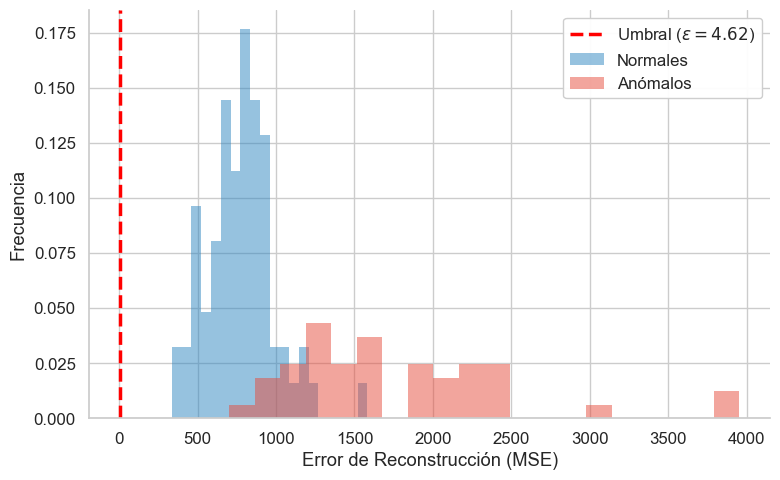

[B] normales=71, anomalías=43, normales > epsilon=71


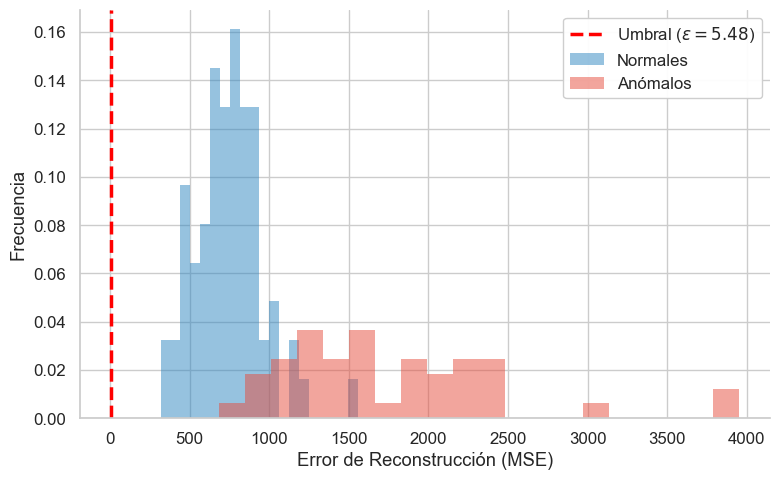

[C] normales=71, anomalías=43, normales > epsilon=71


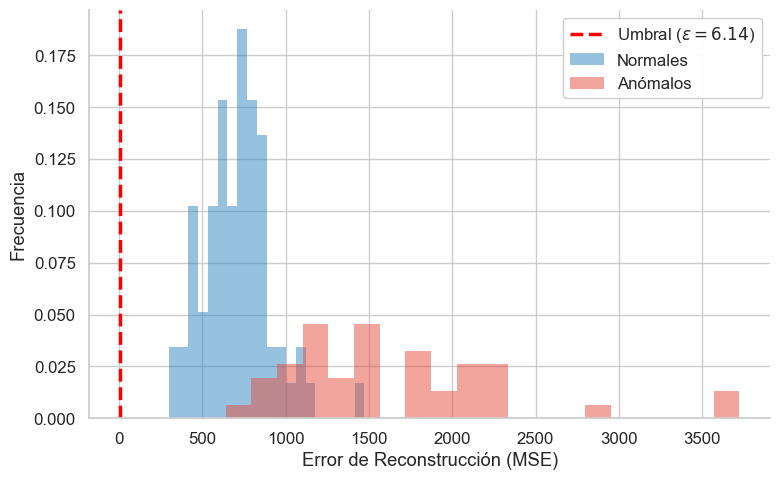

In [31]:
from utils import (evaluar_reconstruccion, obtener_epsilon,graficar_histograma_errores_reconstruccion,
                   obtener_matriz_confusion, obtener_metricas, graficar_matriz_confusion)

modelos = [modelo_A, modelo_B, modelo_C]
x_trains = [x_train_A, x_train_B, x_train_C]
nombres = ["A", "B", "C"]

dif_norm = []
dif_anom = []
epsilons = []

TIPO_NORMA = "L2" #"L1" "L2" "Linf" "MSE"
TIPO_EPSILON = 2

X = x_test
Y = y_test

for modelo in modelos:
    _, dnorm = evaluar_reconstruccion(modelo, X[Y==0], device, tipo_norma=TIPO_NORMA)
    _, danom = evaluar_reconstruccion(modelo, X[Y==1], device, tipo_norma=TIPO_NORMA)
    dif_norm.append(dnorm)
    dif_anom.append(danom)
for modelo, xtrain in zip(modelos, x_trains):
    eps = obtener_epsilon(modelo, xtrain, device, tipo_epsilon=TIPO_EPSILON, tipo_norma=TIPO_NORMA)
    epsilons.append(eps)
for e in epsilons:
    print(round(e, 3))
for nombre, dnorm, danom, eps in zip(nombres, dif_norm, dif_anom, epsilons):
    print(f"[{nombre}] normales={len(X[Y==0])}, anomalías={len(X[Y==1])}, normales > epsilon={np.sum(dnorm > eps)}")
    graficar_histograma_errores_reconstruccion(dnorm, danom, epsilon=eps, kde=False, bins=20, stat="frequency")

# Matriz de confusión y métricas

Luego las métricas se obtienen como:

$$
\begin{array}{rcl rcl}
\text{Accuracy} & = &
\dfrac{\text{TP} + \text{TN}}
      {\text{TP} + \text{FP} + \text{TN} + \text{FN}}
&
\text{Precision} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FP}}
\\[14pt]

\text{Recall} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FN}}
&
\text{Specificity} & = &
\dfrac{\text{TN}}
      {\text{TN} + \text{FP}}
\\[14pt]

\text{Balanced Accuracy} & = &
\dfrac{\dfrac{\text{TP}}{\text{TP}+\text{FN}} + \dfrac{\text{TN}}{\text{TN}+\text{FP}}}{2}
&
\text{F1\_Score} & = &
\dfrac{2\,\text{TP}}
      {2\,\text{TP} + \text{FP} + \text{FN}}
\end{array}
$$

[A] Matriz: TP=43, FN=0, TN=0, FP=71
{'accuracy': 0.3772, 'precision': 0.3772, 'recall': 1.0, 'specificity': 0.0, 'balanced_accuracy': 0.5, 'f1_score': 0.5478}


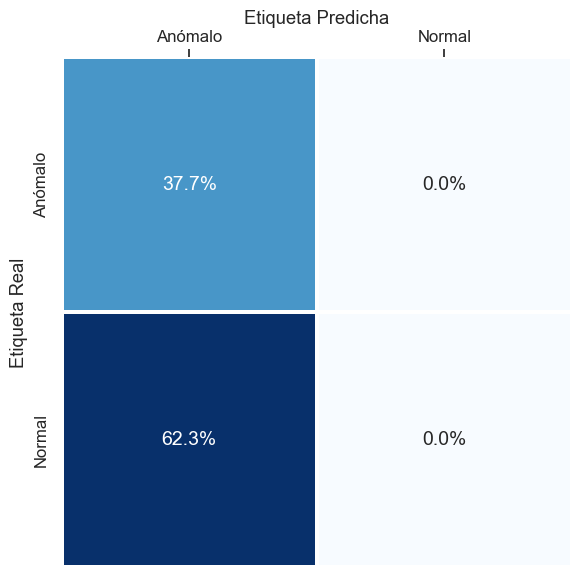

[B] Matriz: TP=43, FN=0, TN=0, FP=71
{'accuracy': 0.3772, 'precision': 0.3772, 'recall': 1.0, 'specificity': 0.0, 'balanced_accuracy': 0.5, 'f1_score': 0.5478}


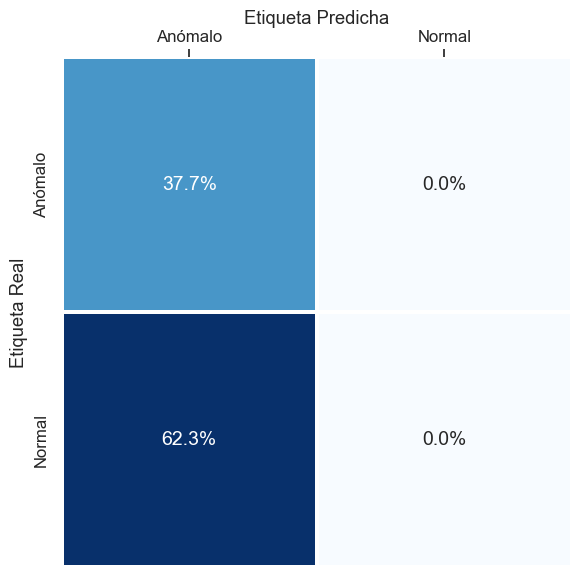

[C] Matriz: TP=43, FN=0, TN=0, FP=71
{'accuracy': 0.3772, 'precision': 0.3772, 'recall': 1.0, 'specificity': 0.0, 'balanced_accuracy': 0.5, 'f1_score': 0.5478}


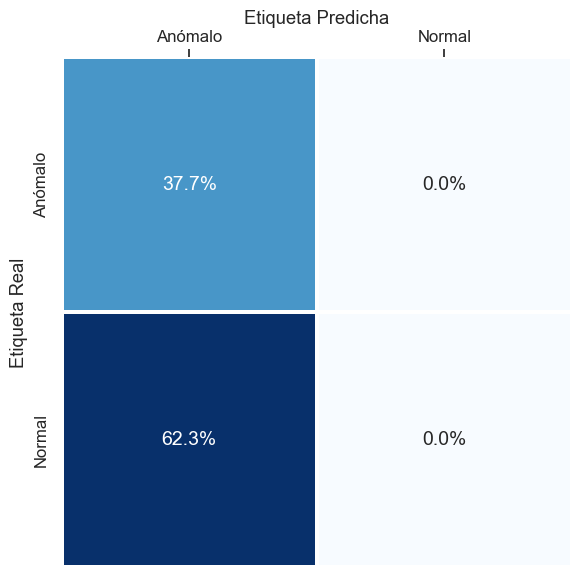

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

for nombre, dnorm, danom, eps in zip(nombres, dif_norm, dif_anom, epsilons):
    TP, FN, TN, FP = obtener_matriz_confusion(dnorm, danom, eps)
    print(f"[{nombre}] Matriz: TP={TP}, FN={FN}, TN={TN}, FP={FP}")
    print(obtener_metricas(TP, FN, TN, FP))
    graficar_matriz_confusion(TP, FN, TN, FP, True)

# Espacio latente

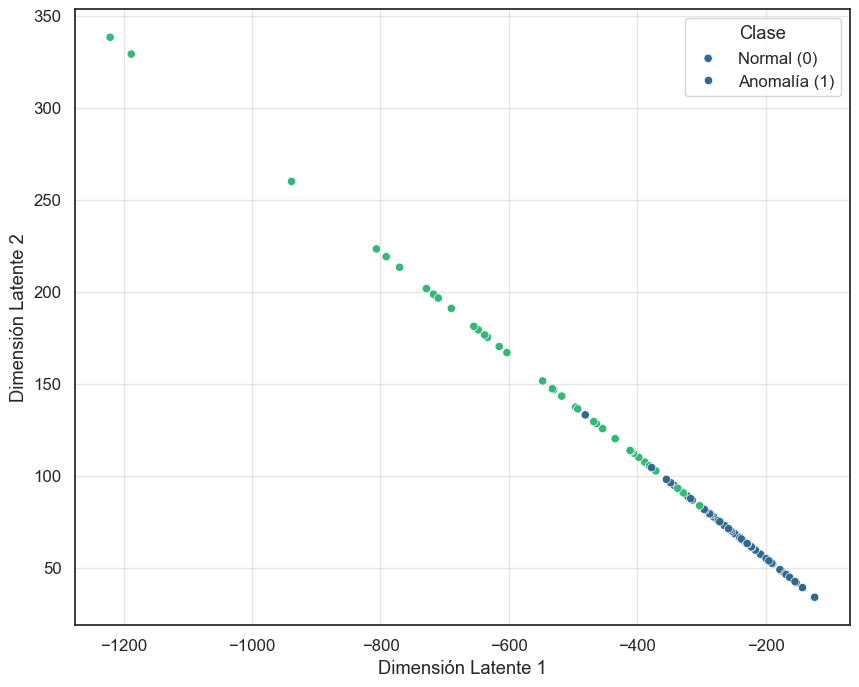

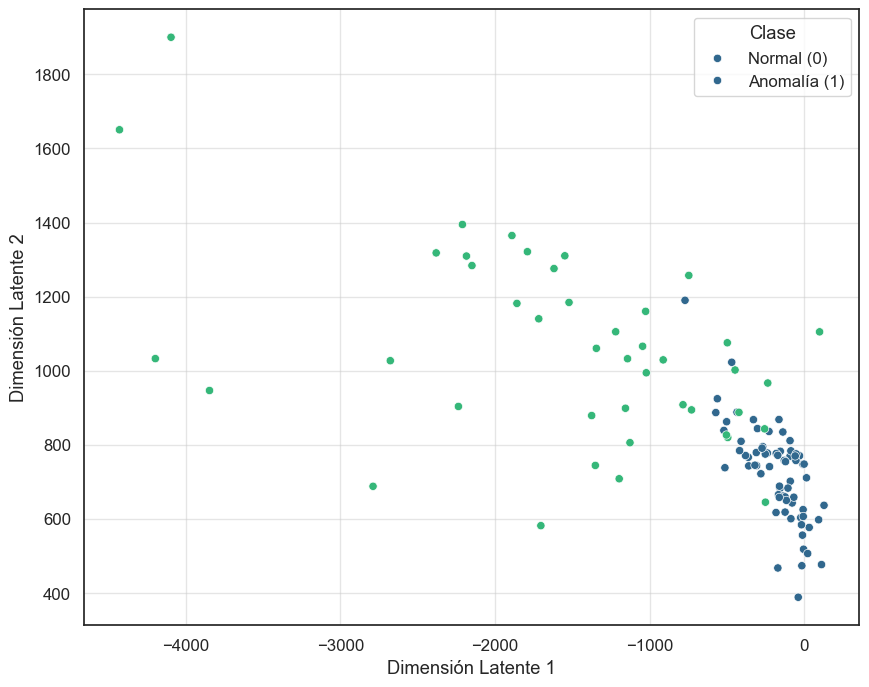

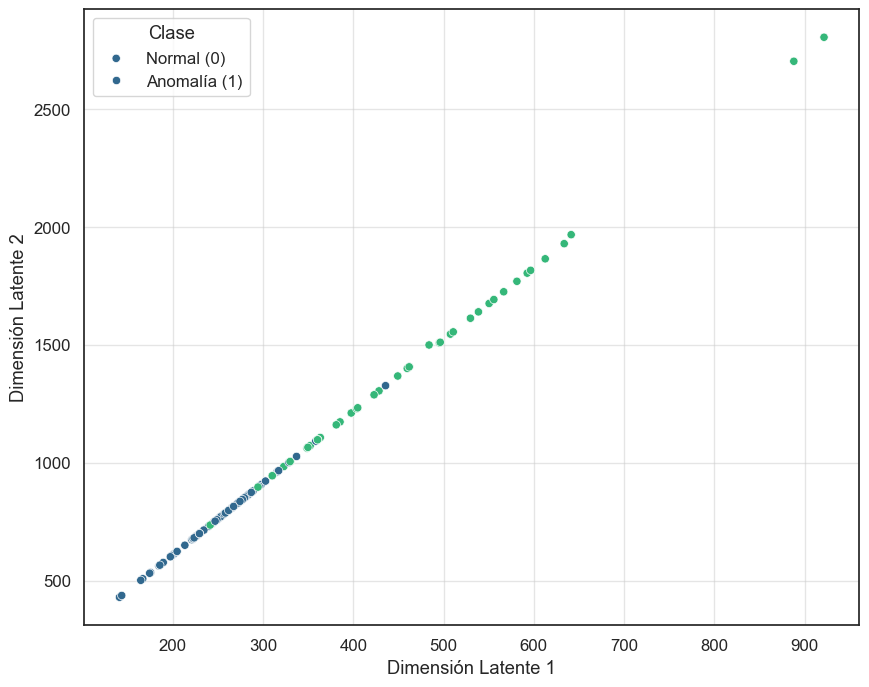

In [23]:
from utils import graficar_espacio_latente

z_A = modelo_A.encode(X, device)

graficar_espacio_latente(z_A, Y, ["Normal (0)", "Anomalía (1)"])

z_B = modelo_B.encode(X, device)

graficar_espacio_latente(z_B, Y, ["Normal (0)", "Anomalía (1)"])

z_C = modelo_C.encode(X, device)

graficar_espacio_latente(z_C, Y, ["Normal (0)", "Anomalía (1)"])

# Curva ROC y AUC

Hacer una curva ROC para cada conjunto (A, B y C)

Tamaño de conjunto de test: 114


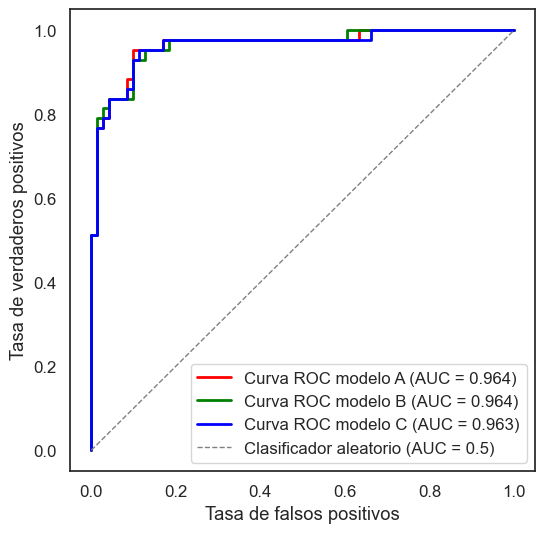

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print(f"Tamaño de conjunto de test: {len(X)}")

_, errores_A = evaluar_reconstruccion(modelo_A, X, device)
_, errores_B = evaluar_reconstruccion(modelo_B, X, device)
_, errores_C = evaluar_reconstruccion(modelo_C, X, device)

fpr_A, tpr_A, thresholds = roc_curve(Y, errores_A)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, thresholds = roc_curve(Y, errores_B)
roc_auc_B = auc(fpr_B, tpr_B)

fpr_C, tpr_C, thresholds = roc_curve(Y, errores_C)
roc_auc_C = auc(fpr_C, tpr_C)

plt.figure(figsize=(6,6))

plt.plot(fpr_A, tpr_A, color='red', lw=2, label=f'Curva ROC modelo A (AUC = {roc_auc_A:.3f})')
plt.plot(fpr_B, tpr_B, color='green', lw=2, label=f'Curva ROC modelo B (AUC = {roc_auc_B:.3f})')
plt.plot(fpr_C, tpr_C, color='blue', lw=2, label=f'Curva ROC modelo C (AUC = {roc_auc_C:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc='lower right')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05 ,1.05])
plt.show()

In [25]:
from sklearn.metrics import roc_auc_score

scores = np.concatenate([dif_norm[1], dif_anom[1]])
labels = np.concatenate([np.zeros(len(dif_norm[1])), np.ones(len(dif_anom[1]))])

auc = roc_auc_score(labels, scores)
print(f"{auc:.3f}")

0.964


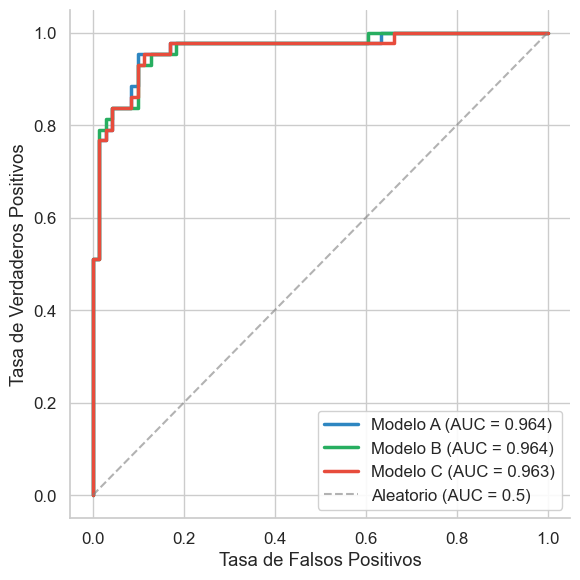

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

_, errores_A = evaluar_reconstruccion(modelo_A, X, device)
_, errores_B = evaluar_reconstruccion(modelo_B, X, device)
_, errores_C = evaluar_reconstruccion(modelo_C, X, device)

fpr_A, tpr_A, _ = roc_curve(Y, errores_A)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, _ = roc_curve(Y, errores_B)
roc_auc_B = auc(fpr_B, tpr_B)

fpr_C, tpr_C, _ = roc_curve(Y, errores_C)
roc_auc_C = auc(fpr_C, tpr_C)

plt.figure(figsize=(6, 6))

colores = {'A': '#2E86C1', 'B': '#27AE60', 'C': '#E74C3C'}

plt.plot(fpr_A, tpr_A, color=colores['A'], lw=2.5, alpha=1, label=f'Modelo A (AUC = {roc_auc_A:.3f})')
plt.plot(fpr_B, tpr_B, color=colores['B'], lw=2.5, alpha=1, label=f'Modelo B (AUC = {roc_auc_B:.3f})')
plt.plot(fpr_C, tpr_C, color=colores['C'], lw=2.5, alpha=1, label=f'Modelo C (AUC = {roc_auc_C:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', alpha=0.6, label='Aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')

plt.legend(loc='lower right', frameon=True, fancybox=True, framealpha=0.9)

sns.despine()

plt.tight_layout()
plt.show()

c:\entornos-gpu\anomaly-detection-with-autoencoder\models.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path, map_location=device)


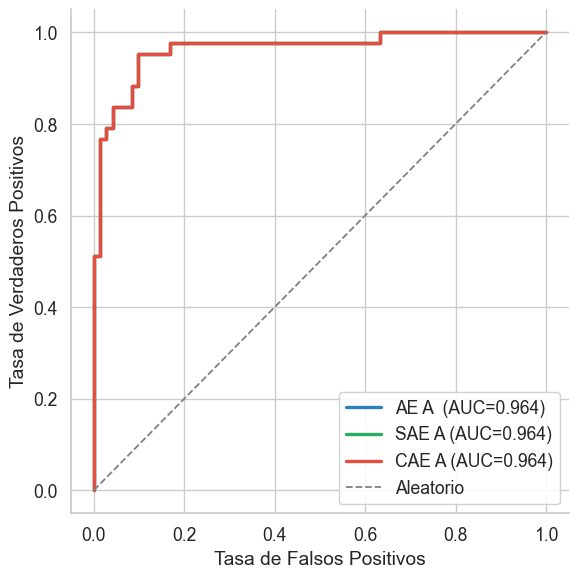

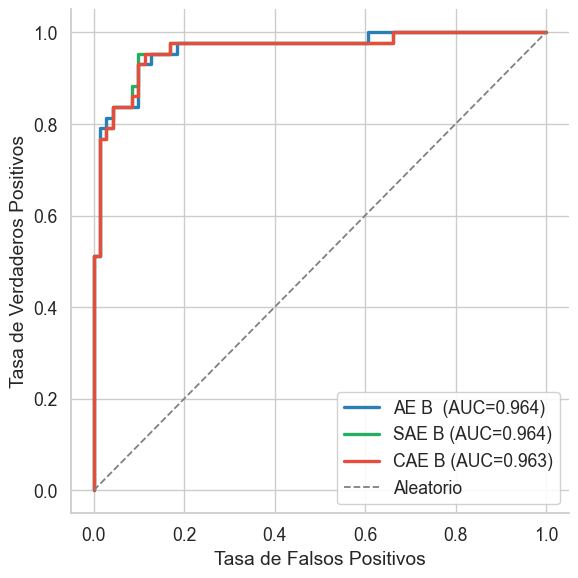

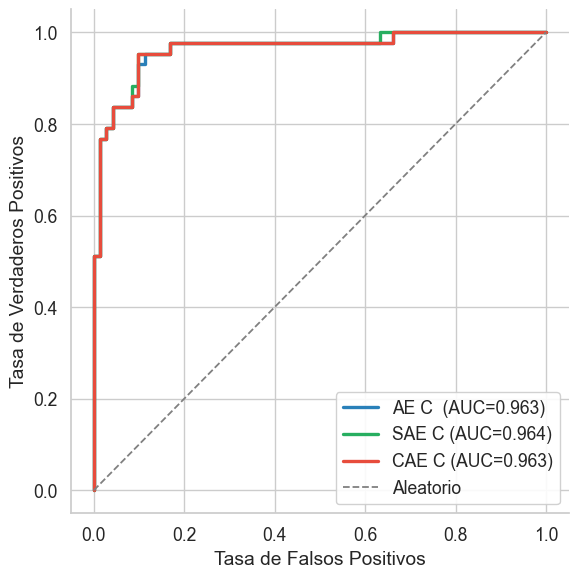

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.15)

# ============================================================
#   CARGA DE MODELOS
# ============================================================

# ---- Modelos A ----
ae_A  = Autoencoder.load("../models/Autoencoder_2025-12-08T20.41_lr=0.0001_set=A.pth", device=device)
sae_A = SAE.load("../models/SAE_2025-12-08T20.45_lr=0.0001_set=A.pth",          device=device)
cae_A = CAE.load("../models/CAE_2025-12-08T20.53_lr=0.001_set=A.pth",           device=device)

# ---- Modelos B ----
ae_B  = Autoencoder.load("../models/Autoencoder_2025-12-08T20.42_lr=0.0001_set=B.pth", device=device)
sae_B = SAE.load("../models/SAE_2025-12-08T20.47_lr=0.0001_set=B.pth",          device=device)
cae_B = CAE.load("../models/CAE_2025-12-08T20.54_lr=0.001_set=B.pth",           device=device)

# ---- Modelos C ----
ae_C  = Autoencoder.load("../models/Autoencoder_2025-12-08T20.43_lr=0.0001_set=C.pth", device=device)
sae_C = SAE.load("../models/SAE_2025-12-08T20.48_lr=0.0001_set=C.pth",          device=device)
cae_C = CAE.load("../models/CAE_2025-12-08T20.54_lr=0.001_set=C.pth",           device=device)


# ============================================================
#   COLORES POR TIPO DE MODELO
# ============================================================

colores = {
    "AE":  "#2980B9",
    "SAE": "#27AE60",
    "CAE": "#E74C3C"
}

# ============================================================
#   GRAFICAR ROC PARA UN TRÍO (AE, SAE, CAE)
# ============================================================

def graficar_roc(model_AE, model_SAE, model_CAE, etiqueta):
    # Errores (puntajes)
    _, err_AE  = evaluar_reconstruccion(model_AE,  X, device)
    _, err_SAE = evaluar_reconstruccion(model_SAE, X, device)
    _, err_CAE = evaluar_reconstruccion(model_CAE, X, device)

    # ROC
    fpr_AE,  tpr_AE,  _ = roc_curve(Y, err_AE)
    fpr_SAE, tpr_SAE, _ = roc_curve(Y, err_SAE)
    fpr_CAE, tpr_CAE, _ = roc_curve(Y, err_CAE)

    auc_AE  = auc(fpr_AE,  tpr_AE)
    auc_SAE = auc(fpr_SAE, tpr_SAE)
    auc_CAE = auc(fpr_CAE, tpr_CAE)

    # --- Figura ---
    plt.figure(figsize=(6, 6))

    plt.plot(fpr_AE,  tpr_AE,  lw=2.4, color=colores["AE"],  label=f"AE {etiqueta}  (AUC={auc_AE:.3f})")
    plt.plot(fpr_SAE, tpr_SAE, lw=2.4, color=colores["SAE"], label=f"SAE {etiqueta} (AUC={auc_SAE:.3f})")
    plt.plot(fpr_CAE, tpr_CAE, lw=2.4, color=colores["CAE"], label=f"CAE {etiqueta} (AUC={auc_CAE:.3f})")

    plt.plot([0,1],[0,1], linestyle="--", color="gray", lw=1.3, label="Aleatorio")

    plt.xlabel("Tasa de Falsos Positivos")
    plt.ylabel("Tasa de Verdaderos Positivos")
    plt.legend(loc="lower right", frameon=True, framealpha=0.9)

    sns.despine()
    plt.tight_layout()
    plt.show()


# ============================================================
#   GENERAR LOS 3 GRÁFICOS: A, B y C
# ============================================================

graficar_roc(ae_A, sae_A, cae_A, "A")
graficar_roc(ae_B, sae_B, cae_B, "B")
graficar_roc(ae_C, sae_C, cae_C, "C")
